In [1]:
import sys
# Add your lenscarf site-packages to the path
sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')

import numpy as np

import matplotlib.pyplot as plt

sys.path.append('/users/odarwish/abacusutils/')

from abacusnbody.data.read_abacus import read_asdf

import numpy as np

from abacusnbody.analysis.tsc import tsc_parallel

import matplotlib.pyplot as plt

from abacusnbody.analysis.power_spectrum import calc_power, calc_pk_from_deltak, get_k_mu_edges
from abacusnbody.analysis import power_spectrum as ps

from scipy.fft import rfftn, irfftn

import astropy

from classy import Class

import yaml

In [2]:
from abacusnbody.analysis.power_spectrum import calc_power
from abacusnbody.data import read_abacus
from pathlib import Path

In [3]:
scratch = "/capstor/scratch/cscs/odarwish/ABACUS/"

In [4]:
z = 0.5

In [66]:
box = 2000
nthread = 256
ngrid = 576#*2

In [67]:
interlaced = True
compensated = True
paste = 'TSC'
nbins_mu = 4
logk = False
k_hMpc_max = np.pi * ngrid / box + 1.0e-6
nbins_k = ngrid // 2
nthread = 128
dtype = np.float32

In [68]:
configuration = '../configs/abacus/config_abacus_recs.yaml'

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

ps_main_directory = config['power_spectrum']['main_directory']
name_config = config['name']
gen_nl_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['nonlinear'])
gen_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['linear'])

In [69]:
output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']

In [70]:
from abacusnbody.metadata import get_meta
from abacusnbody.hod.zcv.ic_fields import load_dens, load_disp

sim_name = f"{config['sim_params']['sim_name_base']}{0:03}"
z = config['sim_params']['z_mock']

meta = get_meta(sim_name, redshift=z)

z_ic = meta['InitialRedshift']

Dz = meta['GrowthTable']
ztarget = 0.5
zpk = meta['ZD_Pk_file_redshift']  # 1.0
pk = meta['CLASS_power_spectrum']
linear_k  = pk['k (h/Mpc)']
input_pk = pk['P (Mpc/h)^3']
linear_pk = input_pk * (Dz[ztarget] / Dz[zpk])**2

In [71]:
D_ratio = meta['GrowthTable'][meta['Redshift']] / meta['GrowthTable'][z_ic]
D_ratio

59.91148545808563

In [74]:
ic_dir = "/users/odarwish/scratch/ABACUS/ic/"
#ic = load_dens(ic_dir, sim_name, ngrid)

In [75]:
ic = load_dens(ic_dir, sim_name, ngrid)
ic_fft = rfftn(ic, overwrite_x=False, workers=nthread)
ic_fft /= ic.size

In [13]:
#ic = load_dens(ic_dir, sim_name, ngrid)
from jax import numpy as jnp

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']

In [14]:
sys.path.append('/users/odarwish/qeep/')
from qeep import rec, rec_utils as ru

In [40]:
z_mock = 0.5
scratch = f"/users/odarwish/scratch/ABACUS/abacus_out/{sim_name}/z{z_mock:.3f}/galaxies/"
samples = ["LRG", "ELG"]
out_info_A = np.load(scratch+f"{samples[0]}_out_info.npy", allow_pickle=True).item()
out_info_B = np.load(scratch+f"{samples[1]}_out_info.npy", allow_pickle=True).item()


kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

Ks = np.linspace(k_min_analysis, k_max_analysis, k_samples)

filename_prefix = output_config['filename_prefix']+f"{sim_name}_z{z_mock:.3f}_{samples[0]}_{samples[1]}"
out_normalization_AB = np.load(output_dir / f"{filename_prefix}_normalization_AB.npy", allow_pickle=True).item()
out_variance_AB = np.load(output_dir / f"{filename_prefix}_variance_AB.npy", allow_pickle = True).item()

In [16]:
W = ps.get_W_compensated(box, ngrid, paste, interlaced)

f = (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
    )


In [56]:
#ic_growth = rec.get_growth_rec(ic*D_ratio/ic.size, box, kmin, kmax, pnlinf, plinf)

In [18]:
out_info_A.keys()

dict_keys(['b1', 'b2', 'bs', 'b2_L', 'bs_L', 'nbar', 'z', 'Ptot', 'Ptot_L', 'PNL', 'PL', 'k', 'Pmeasured', 'k_measured'])

In [81]:
from astropy.io import ascii
scratch = "/users/odarwish/scratch/ABACUS/abacus_out/AbacusSummit_base_c000_ph000/z0.500/galaxies/"
"""
nome = scratch+"LRGs.dat"
LRG = ascii.read(nome)

nome = scratch+"ELGs.dat"
ELG = ascii.read(nome)


N_lrg = LRG['x'].size
N_elg = ELG['x'].size
N_lrg, N_elg


box = 2000
V = box**3
n_lrg = N_lrg/V
n_elg = N_elg/V
shot_lrg = 1/n_lrg
shot_elg = 1/n_elg


box = 2000
nthread = 256
ngrid = 576#*2

interlaced = True
compensated = True
paste = 'TSC'

from abacusnbody.analysis import tsc
pos = np.vstack([LRG['x'], LRG['y'], LRG['z']]).T
delta_LRG = tsc.tsc_parallel(pos+box/2, ngrid, box, nthread=nthread)
delta_LRG /= np.mean(delta_LRG, dtype=np.float64)
delta_LRG -= 1.

pos = np.vstack([ELG['x'], ELG['y'], ELG['z']]).T
delta_ELG = tsc.tsc_parallel(pos+box/2, ngrid, box, nthread=nthread)
delta_ELG /= np.mean(delta_ELG, dtype=np.float64)
delta_ELG -= 1.
"""

delta_LRG = np.load(scratch+"LRG_delta_g.npy")
delta_ELG = np.load(scratch+"ELG_delta_g.npy")

In [25]:
kA = out_info_A["k"]
kB = out_info_B["k"]

PAA = out_info_A["Ptot"]
PBB = out_info_B["Ptot"]

pnlinf_A = lambda kmag: jnp.interp(kmag, kA, PAA)
pnlinf_B = lambda kmag: jnp.interp(kmag, kB, PBB)


In [27]:
ic_shift_AB = rec.get_shift_n_rec(delta_LRG, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = delta_ELG, Ptot_interp_2 = pnlinf_B)

In [88]:
k, p = ru.calc_power_mu0_x_axis(ic_shift_AB.astype(complex), box, delta_k2 = ic_fft*D_ratio/ic.size)
p = np.interp(Ks, k, p)

In [ ]:
def plot(key, power, cross = False):

    # ---- FIGURE CREATION ----
    # Create figure with golden ratio and higher dpi
    fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
    # Use GridSpec for more control over plot layout
    gs = GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
    ax = fig.add_subplot(gs[0, 0])
    caso = "auto" if not cross else "cross"
    ax.set_title(f"{names[key]} {caso}")
    
    # Professional tick parameters
    ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
                   top=True, right=False, labelsize=10)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
                   top=True, right=False)


    
    non_linear_pk_interp = np.interp(Ks, gen_nl_power[:,0], gen_nl_power[:,1])
    
    N = out_normalization_AB[(key, key)]**-1.
    v = out_variance_AB[(key, key)]
    variance = N**2*v

    
    if not cross:
        i = 0
        color = COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)]
        ax.plot(Ks, N, label = "Normalization Noise", color = color)
        i = 1
        color = COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)]
        ax.plot(Ks, N**2*v, label = "Variance", ls = "--", color = color)

    size = 191102976
    factor = 1/size**2
    
    bias = 0
    kinds = ["s", "t", "g"]
    for kk in kinds:
        bias += (N*out_normalization_AB[(key, kk)])
    
    linear_pk_interp = np.interp(Ks, gen_power[:,0], gen_power[:,1])
    i = 3
    color = COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)]
    if cross:
        ax.loglog(Ks, abs(bias)*linear_pk_interp, ls = "--", color = color, label = "Prediction")
        V = 1000**3
        Nmodes = V*(Ks**2*(Ks[1]-Ks[0]))
        err2 = (bias**2*linear_pk_interp+variance)*linear_pk_interp+(abs(bias)*linear_pk_interp)**2
        err_bar_cross = np.sqrt(err2/Nmodes)
    else:
        ax.loglog(Ks, bias**2*linear_pk_interp+v*N**2, ls = "--", color = color, label = "Prediction")
    
    a, b = k_values, power*factor**(1+int(cross==False))
    b[0] = 0.
    b = b.astype(float)
    value = np.interp(Ks, a, b)*N**(1+int(cross==False))
    #if cross:
    #    ax.errorbar(Ks, value, err_bar_cross, label = "Reconstruction", color = "black", alpha = 0.4, ls = "", marker = "o")
    #else:
    ax.scatter(Ks, (value), label = "Reconstruction", color = "black", alpha = 0.4)
    
    #plt.ylim(1e-6, 1)
    #ax.set_xlim(2e-3, 1e-1)
    ax.set_xlim(2e-3, 5e-2)
    #ax.set_yscale("symlog", linthresh = 1e-1)

    #ax.set_xlabel(r'$K \ \mathrm{[h/Mpc]}$', fontsize=16)
    #ax.set_ylabel(r'$P(K) \mathrm{[h^3/Mpc^{3}]}$', fontsize=16)
    #ax.set_yscale("linear")
    ax.legend()

    fig.savefig(f"../plots/{key}_{caso}.pdf", dpi = 300)
    plt.show()
    plt.close()

In [96]:
trA, trB = "LRG", "ELG"
trA, trB = "LRG", "LRG"

path = "/users/odarwish/qeep/results/abacus_recs/"
norm = np.load(path+f"analysisAbacusSummit_base_c000_ph000_z0.500_{trA}_{trB}_normalization_AB.npy", allow_pickle = True).item()
var = np.load(path+f"analysisAbacusSummit_base_c000_ph000_z0.500_{trA}_{trB}_variance_AB.npy", allow_pickle = True).item()
shot = np.load(path+f"analysisAbacusSummit_base_c000_ph000_z0.500_{trA}_{trB}_cross_shot_AB.npy", allow_pickle = True).item()

In [102]:
Fg_factor = 17/21
g = lambda out_biases_A, out_biases_B: (out_biases_A['b1']+Fg_factor*1/2*out_biases_A['b2'])*out_biases_B['b1']
s = lambda out_biases_A, out_biases_B: out_biases_A['b1']*out_biases_B['b1']
t = lambda out_biases_A, out_biases_B:  (out_biases_A['b1']+7/2*out_biases_A['bs'])*out_biases_B['b1']

biases_rec = {"g": g(out_info_A, out_info_B), "s": s(out_info_A, out_info_B), "t": t(out_info_A, out_info_B)}

(0.1751796805063328, 1000000.0)

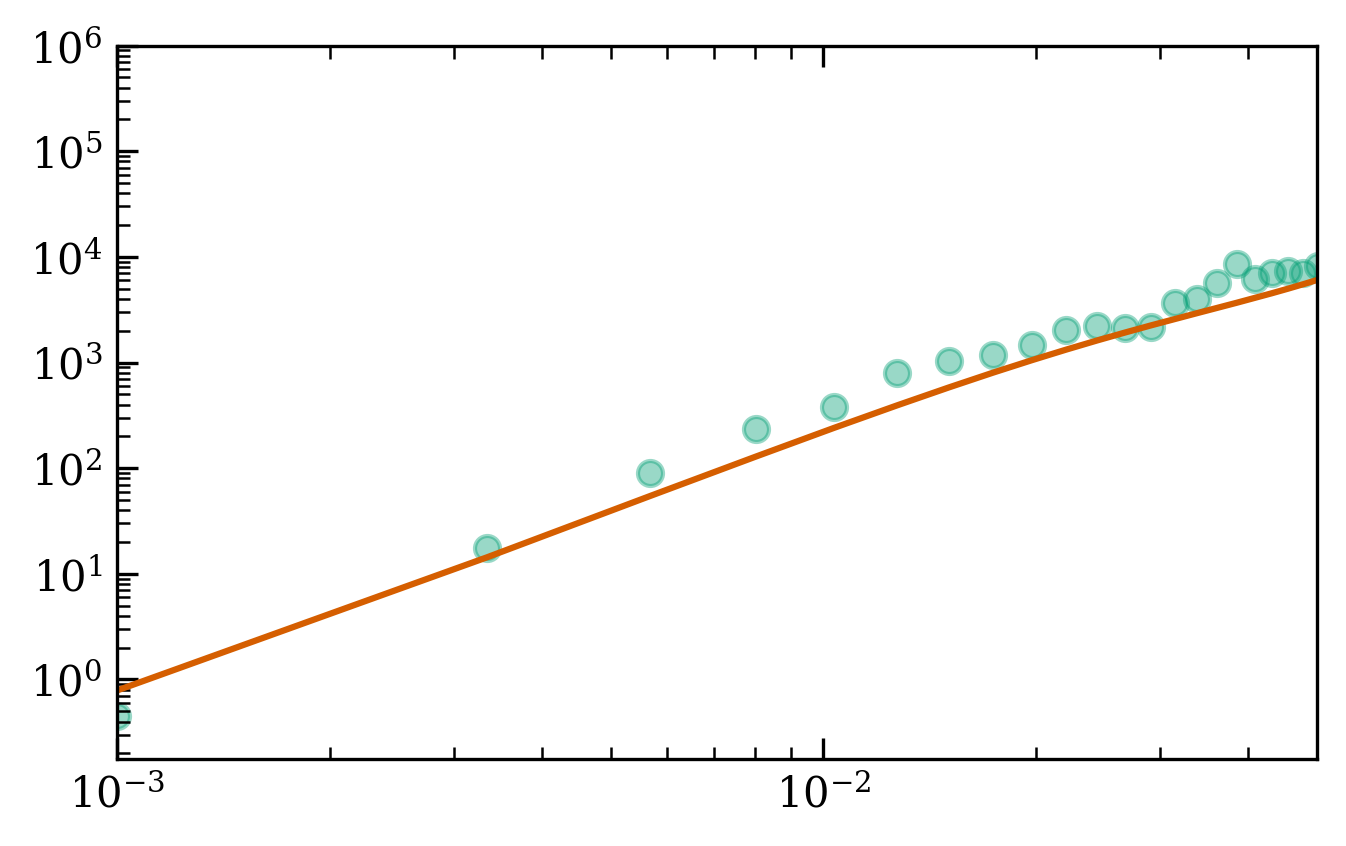

In [137]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
from matplotlib.gridspec import GridSpec
from matplotlib import patheffects
import matplotlib as mpl


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm"  # Use Computer Modern math font
})


COLORBLIND_PALETTE = [
    '#0072B2',  # Blue
    '#D55E00',  # Orange
    '#009E73',  # Green
    '#CC79A7',  # Pink
    '#56B4E9',  # Light blue
    '#E69F00',  # Yellow
    '#000000',  # Black
    '#F0E442'   # Light yellow
]

# Use golden ratio for figure dimensions
GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 5  # inches
FIG_HEIGHT = FIG_WIDTH * GOLDEN_RATIO
DPI = 300


fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
                   top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

key = "n"

size = 191102976
factor = 1/size

N = out_normalization_AB[(key, key)]**-1.
shot_noise = shot[(key, key)]*N
#plt.loglog(Ks, N, ls = "--", lw = 2, color = "b")
ax.scatter(Ks, p*N*factor/2, color = COLORBLIND_PALETTE[2], alpha = 0.4)


bias = 0
kinds = ["s", "t", "g"]
for kk in kinds:
    bias += (N*out_normalization_AB[(key, kk)])
ax.loglog(Ks, -bias*plinf(Ks)-shot_noise, color = COLORBLIND_PALETTE[1])

#ax.loglog(Ks, -bias*plinf(Ks), color = COLORBLIND_PALETTE[4], ls = "--")

ax.set_xlim(1e-3, 0.05)
ax.set_ylim(ymax = 1e6)

In [21]:
delta_A = ic*D_ratio/ic.size * out_info_A["b1"] 
delta_B = ic*D_ratio/ic.size * out_info_B["b1"]

kA = out_info_A["k"]
kB = out_info_B["k"]

PAA = out_info_A["Ptot"]
PBB = out_info_B["Ptot"]

pnlinf_A = lambda kmag: jnp.interp(kmag, kA, PAA)
pnlinf_B = lambda kmag: jnp.interp(kmag, kB, PBB)

ic_growth_AB = rec.get_growth_rec(delta_A, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = delta_B, Ptot_interp_2 = pnlinf_B)

In [22]:
pnlinf_A = lambda kmag: jnp.interp(kmag, gen_nl_power[:, 0], gen_nl_power[:, 1]*out_info_A["b1"]**2)
pnlinf_B = lambda kmag: jnp.interp(kmag, gen_nl_power[:, 0], gen_nl_power[:, 1]*out_info_B["b1"]**2)

ic_growth_AB_alt = rec.get_growth_rec(delta_A, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = delta_B, Ptot_interp_2 = pnlinf_B)

In [23]:
#ic_growth_AB = rec.get_shift_rec(delta_A, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = delta_B, Ptot_interp_2 = pnlinf_B)

In [24]:
k, p = ru.calc_power_mu0_x_axis(ic_growth, box)
k, pAB = ru.calc_power_mu0_x_axis(ic_growth_AB, box)
k, pAB_alt = ru.calc_power_mu0_x_axis(ic_growth_AB_alt, box)

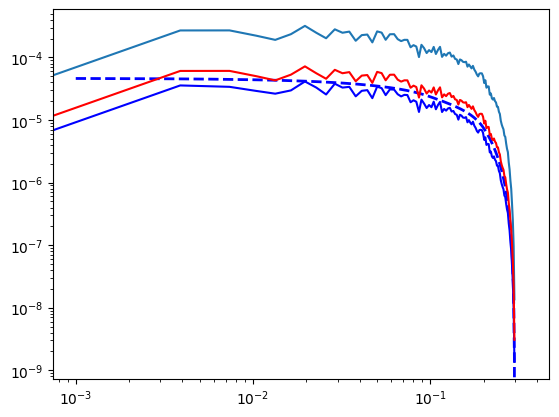

In [25]:
key = "g"
plt.loglog(Ks, out_normalization_AB[(key, key)], ls = "--", lw = 2, color = "b")
plt.plot(k, p)
plt.plot(k, pAB, color = "b")
plt.plot(k, pAB_alt, color = "r")

In [26]:
path = "/users/odarwish/qeep/results/abacus_recs/"

In [27]:
trA, trB = "LRG", "ELG"
trA, trB = "LRG", "LRG"

norm = np.load(path+f"analysisAbacusSummit_base_c000_ph000_z0.500_{trA}_{trB}_normalization_AB.npy", allow_pickle = True).item()

In [95]:
trA, trB = "LRG", "ELG"
trA, trB = "LRG", "LRG"

path = "/users/odarwish/qeep/results/abacus_recs/"
norm = np.load(path+f"analysisAbacusSummit_base_c000_ph000_z0.500_{trA}_{trB}_normalization_AB.npy", allow_pickle = True).item()
var = np.load(path+f"analysisAbacusSummit_base_c000_ph000_z0.500_{trA}_{trB}_variance_AB.npy", allow_pickle = True).item()
shot = np.load(path+f"analysisAbacusSummit_base_c000_ph000_z0.500_{trA}_{trB}_cross_shot_AB.npy", allow_pickle = True).item()

In [29]:
shot = np.load(path+f"analysisAbacusSummit_base_c000_ph000_z0.500_{trA}_{trB}_cross_shot_AB.npy", allow_pickle = True).item()

In [30]:
Ks = np.load(path+f"analysisAbacusSummit_base_c000_ph000_z0.500_{trA}_{trB}_Ks.npy")

In [31]:
def plot(key, k, power, cross = False):
    non_linear_pk_interp = np.interp(Ks, gen_nl_power[:,0], gen_nl_power[:,1])
    
    N = norm[(key, key)]**-1.
    v = var[(key, key)]

    if not cross:
        plt.plot(Ks, N, label = "Normalization Noise")
        plt.plot(Ks, N**2*v, label = "Variance", ls = "--")
    
    bias = 0
    kinds = ["s", "t", "g"]
    for kk in kinds:
        bias += (N*out_normalization_AB[(key, kk)])
    
    linear_pk_interp = jnp.interp(Ks, linear_k, linear_pk)
    if cross:
        plt.loglog(Ks, abs(bias)*linear_pk_interp, ls = "--")
    else:
        plt.loglog(Ks, bias**2*linear_pk_interp+N**2*v+N*shot[(key, key)], ls = "--")

    factor = 1.
    
    a, b = k, power*factor**(1+int(cross==False))
    b[0] = 0.
    b = b.astype(float)
    value = np.interp(Ks, a, b)*N**(1+int(cross==False))
    plt.loglog(Ks, abs(value), ls = "--", label = "Reconstruction", color = "black")
    
    #plt.ylim(1e-6, 1)
    plt.xlim(2e-3, 2e-1)
    
    plt.legend()

    plt.show()

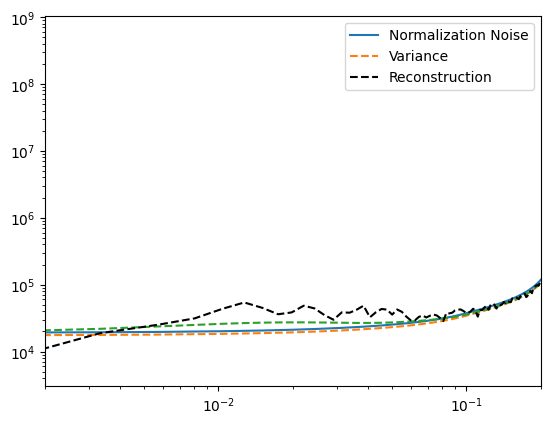

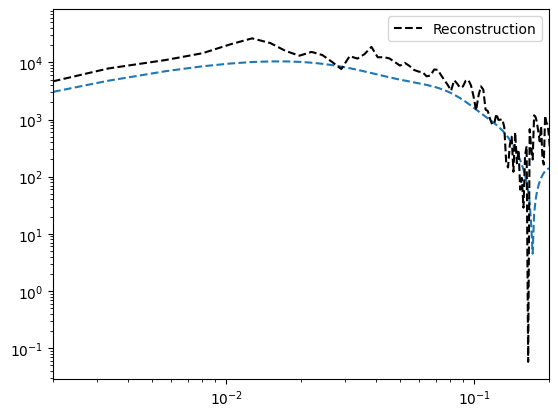

In [34]:
cases = ["auto", "cross"]

for case in cases:
    power = 0
    Nsims = 1
    for j in range(Nsims):
        res = np.load(path+f"results_analysis_{j}.npy", allow_pickle = True).item()
        k, power_ = res["g"][case]
        power += power_
    power = power/Nsims
    plot("g", k, power, case == "cross")

In [ ]:
import jax
import jax.numpy as jnp

In [ ]:
kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']

get_gauss_filter = lambda R: (lambda K: np.exp(-K**2*R**2/2))
R = 1/kmax
gauss_filter = get_gauss_filter(R)

In [ ]:
delta_A = field_fft*1/Ptot_interp*selection
delta_B = field_fft*1/Ptot_interp*Plin_interp*selection

delta_B_real = irfftn(delta_B, overwrite_x=True, workers=nthread)

inv_kmag = np.nan_to_num(1/kmag)
inv_kmag[0, 0, 0] = 0

delta_1 = 0
for i in range(3):
    delta_1_i = kgrid[i]*inv_kmag**2*delta_A
    delta_A_real_i = irfftn(delta_1_i, overwrite_x=True, workers=nthread)
    temp_i = delta_A_real_i*delta_B_real
    fft_temp_i = rfftn(temp_i, overwrite_x=False, workers=nthread)
    fft_temp_i *= kgrid[i]
    delta_1 += fft_temp_i

delta_2 = 0
for i in range(3):
    delta_1_i = kgrid[i]*delta_A
    delta_A_real_i = irfftn(delta_1_i, overwrite_x=True, workers=nthread)
    temp_i = delta_A_real_i*delta_B_real
    fft_temp_i = rfftn(temp_i, overwrite_x=False, workers=nthread)
    fft_temp_i *= kgrid[i]*inv_kmag**2
    delta_2 += fft_temp_i

delta_final = -2*0.5*(delta_1+delta_2)

product_fft = delta_final#rfftn(delta_final, overwrite_x=False, workers=nthread)
#product_fft *= product.size

power_product_shift = calc_pk_from_deltak(
    product_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
from scipy.fft import rfftn, irfftn

inv_kmag2 = np.zeros_like(kgrid[0])
kmag2 = np.sum(kgrid**2, axis=0)
inv_kmag2[kmag2 > 0] = 1.0 / kmag2[kmag2 > 0]  # avoid div by 0

out_rfield = 0
for idir in range(3):
    k_i = kgrid[idir]
    
    # Psi_i(k) = -i * k_i * delta(k) / k^2
    Psi_i_k = -1j * k_i * field_fft * inv_kmag2
    Psi_i_x = irfftn(Psi_i_k, overwrite_x=True, workers=nthread)#*Psi_i_k.size

    # grad_i delta(k) = -i * k_i * delta(k)
    grad_i_k = -1j * k_i * field_fft
    grad_i_x = irfftn(grad_i_k, overwrite_x=True, workers=nthread)#*grad_i_k.size

    # Real-space product: Psi_i(x) * grad_i delta(x)
    out_rfield += Psi_i_x * grad_i_x

# Final result in Fourier space
out_fft = rfftn(out_rfield, overwrite_x=False, workers=nthread)
#out_fft /= out_fft.size

power_out = calc_pk_from_deltak(
    out_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
with open('config_abacus_2.yaml', 'r') as f:
    config2 = yaml.safe_load(f)
output_config2 = config2['output']
filename_prefix = output_config2['filename_prefix']
filename_prefix = output_config2['filename_prefix']
output_dir2 = Path(output_config2['directory'])/config2['name']
out_normalization_AB_2 = np.load(output_dir2 / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()

In [ ]:
out = np.load(f"out.npy", allow_pickle = True).item()

In [ ]:
index = 1

plt.loglog(power_ic['k_avg'][:, index], power_ic['power'][:, index], ls = "--", c = "r")

plt.plot(gen_power[:,0], gen_power[:,1], ls='--', c='g')

plt.xlabel("k")
plt.ylabel("P")
plt.xlim(kmin_vol)
#plt.ylim(100)

In [ ]:
field_fft = rfftn(delta, overwrite_x=False, workers=nthread)

#field_fft = rfftn(delta, overwrite_x=True, workers=nthread)
#field_fft /= (
#    W[:, np.newaxis, np.newaxis]
#    * W[np.newaxis, :, np.newaxis]
#    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
#)

Ptot_interp = jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
gen_power = np.loadtxt(config['power_spectrum']['linear'])
Plin_interp = jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']
selection = (kmag>=kmin) & (kmag<=kmax)
selection = gauss_filter(kmag)

delta_A = field_fft*1/Ptot_interp*selection
delta_B = field_fft*1/Ptot_interp*Plin_interp*selection

delta_A_real = irfftn(delta_A, overwrite_x=True, workers=nthread)
delta_B_real = irfftn(delta_B, overwrite_x=True, workers=nthread)

product = delta_A_real*delta_B_real*17/21

product_fft = rfftn(product, overwrite_x=False, workers=nthread)
product_fft *= 1 / product.size

power_product = calc_pk_from_deltak(
    product_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
index = 1

#plt.plot(gen_nl_power[:,0], gen_nl_power[:,1], ls='--', c='g')

idxs = [0]#, 1, 2, 3, 4]
mean = 0
for sim_idx in idxs:
    power_product_file = np.load(output_dir/f'power_product_{sim_idx:03}.npy', allow_pickle = True).item()
    N = out_normalization_AB[('g', 'g')]**-1.
    p = np.interp(Ks, power_product_file['k_avg'][:, index], power_product_file['power'][:, index])*N**2
    plt.plot(Ks, p, alpha = 0.3)
    mean += p
    
plt.plot(Ks, N, color = "black")

plt.plot(Ks, out_normalization_AB_2[('g', 'g')]**-1., color = "red", ls = "--")

#plt.plot(Ks, mean/len(idxs), color = "blue")

p = np.interp(Ks, power_product['k_avg'][:, index], power_product['power'][:, index])*N**2
plt.plot(Ks, p, ls = "--")

key = "g"
kinds = ["s", "t", "g"]
N = out_normalization_AB_2[(key, key)]**-1.
bias = 0
for k in kinds:
    bias += N*out_normalization_AB_2[(key, k)]
total = bias**2*np.interp(Ks, gen_power[:,0], gen_power[:,1])+N
plt.plot(Ks, total, lw = 2)


#plt.plot(out["Ks"], out[('s', 's')]**-1.)


plt.xlabel("k")
plt.ylabel("P")
plt.xlim(kmin_vol, 0.25)
plt.ylim(ymin = 100, ymax = 2e4)
plt.xscale("log")
#plt.ylim(100)

In [ ]:
plt.plot(Ks, np.interp(Ks, power_product['k_avg'][:, index], power_product_shift['power'][:, index])*N**2)
plt.plot(Ks, np.interp(Ks, power_product['k_avg'][:, index], power_out['power'][:, index])*N**2)


kinds = ["s", "t", "g"]
N = out_normalization_AB[('s', 's')]**-1.
bias = 0
for k in kinds:
    bias += N*out_normalization_AB[('s', k)]
total = bias**2*np.interp(Ks, gen_power[:,0], gen_power[:,1])+N
plt.plot(Ks, total)
plt.loglog(Ks, N, color = "red")